# 📊 Sales Analytics Dashboard

## Project Overview

This project analyzes the Global Superstore dataset using Python.

The goal is to understand sales, profit, customers, regions, and products.

# Data Understanding

In this section, we explore the dataset before starting the business analysis.

In [3]:
import pandas as pd

# Load the Excel file
df = pd.read_excel("../data/raw/Global_Superstore2.xlsx")

# Show the first 5 rows
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,32298,CA-2012-124891,31-07-2012,31-07-2012,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical
1,26341,IN-2013-77878,05-02-2013,07-02-2013,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical
2,25330,IN-2013-71249,17-10-2013,18-10-2013,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium
3,13524,ES-2013-1579342,28-01-2013,30-01-2013,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium
4,47221,SG-2013-4320,05-11-2013,06-11-2013,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical


In [2]:
# Dataset size
print("Shape of dataset:")
print(df.shape)

print("\n")

Shape of dataset:
(51290, 24)




In [3]:
print(df.columns)

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'City', 'State', 'Country',
       'Postal Code', 'Market', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit', 'Shipping Cost', 'Order Priority'],
      dtype='str')


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          51290 non-null  int64  
 1   Order ID        51290 non-null  str    
 2   Order Date      51290 non-null  str    
 3   Ship Date       51290 non-null  str    
 4   Ship Mode       51290 non-null  str    
 5   Customer ID     51290 non-null  str    
 6   Customer Name   51290 non-null  str    
 7   Segment         51290 non-null  str    
 8   City            51290 non-null  str    
 9   State           51290 non-null  str    
 10  Country         51290 non-null  str    
 11  Postal Code     9994 non-null   float64
 12  Market          51290 non-null  str    
 13  Region          51290 non-null  str    
 14  Product ID      51290 non-null  str    
 15  Category        51290 non-null  str    
 16  Sub-Category    51290 non-null  str    
 17  Product Name    51290 non-null  str    
 1

In [5]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit,Shipping Cost
count,51290.00000,9994.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,25645.50000,55190.379428,246.490581,3.476545,0.142908,28.610982,26.375915
std,14806.29199,32063.693350,487.565361,2.278766,0.212280,174.340972,57.296804
min,1.00000,1040.000000,0.444000,1.000000,0.000000,-6599.978000,0.000000
25%,12823.25000,23223.000000,30.758625,2.000000,0.000000,0.000000,2.610000
50%,25645.50000,56430.500000,85.053000,3.000000,0.000000,9.240000,7.790000
75%,38467.75000,90008.000000,251.053200,5.000000,0.200000,36.810000,24.450000
max,51290.00000,99301.000000,22638.480000,14.000000,0.850000,8399.976000,933.570000


In [6]:
df.isnull().sum()

Row ID                0
Order ID              0
Order Date            0
Ship Date             0
Ship Mode             0
Customer ID           0
Customer Name         0
Segment               0
City                  0
State                 0
Country               0
Postal Code       41296
Market                0
Region                0
Product ID            0
Category              0
Sub-Category          0
Product Name          0
Sales                 0
Quantity              0
Discount              0
Profit                0
Shipping Cost         0
Order Priority        0
dtype: int64

# Sales Analytics Project Report

## Business Question 1

### Question

What are the total sales and total profit?

### Python Used

```python
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()

print(f"Total Sales : ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
```

### Result

Total Sales: $12,642,501.91

Total Profit:$1,467,457.29

### Business Insight

The company generated total sales of $12,642,501.91 and earned a total profit of $1,467,457.29 during the analysis period.

This provides an overview of the company's financial performance and serves as a baseline for further analysis.

In [8]:
# ============================
# Business Question 2
# Sales by Category
# ============================

category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

print(category_sales)

Category
Technology         4.744557e+06
Furniture          4.110874e+06
Office Supplies    3.787070e+06
Name: Sales, dtype: float64


---

## Business Question 2

### Question

Which product category generated the highest sales?

### Python Used

```python
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

print(category_sales)
```

### Result

| Category | Total Sales |
|----------|------------:|
| Technology | $4,744,557 |
| Furniture | $4,110,874 |
| Office Supplies | $3,787,070 |

### Business Insight

Technology generated the highest sales, making it the company's top-performing category. Furniture ranked second, while Office Supplies contributed the lowest total sales. This suggests that the company should continue investing in Technology products while exploring strategies to improve the performance of the other categories.

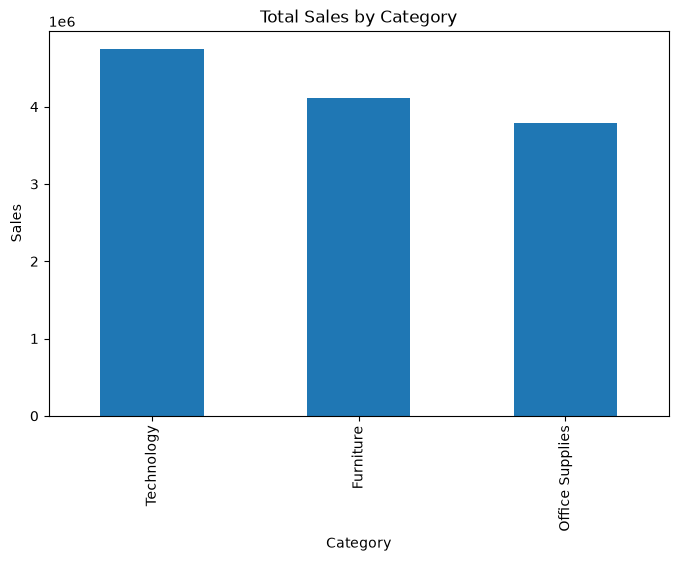

In [10]:
import matplotlib.pyplot as plt

# Sales by Category
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
category_sales.plot(kind="bar")

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")

# Save the chart
plt.savefig("../images/sales_by_category.png", dpi=300, bbox_inches="tight")

plt.show()

# Business Question 3

## Question

Which Sub-Category generates the highest sales?

## Python Used
```
sub_category_sales = df.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False)

print(sub_category_sales)
```

## Result

(Will be filled after running the code.)

## Business Insight

(Will be filled after analysis.)

In [4]:
# ======================================
# Business Question 3
# Sales by Sub-Category
# ======================================

sub_category_sales = (
    df.groupby("Sub-Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

print(sub_category_sales)

Sub-Category
Phones         1.706824e+06
Copiers        1.509436e+06
Chairs         1.501682e+06
Bookcases      1.466572e+06
Storage        1.127086e+06
Appliances     1.011064e+06
Machines       7.790601e+05
Tables         7.570419e+05
Accessories    7.492370e+05
Binders        4.619115e+05
Furnishings    3.855783e+05
Art            3.720920e+05
Paper          2.442917e+05
Supplies       2.430742e+05
Envelopes      1.709043e+05
Fasteners      8.324232e+04
Labels         7.340403e+04
Name: Sales, dtype: float64


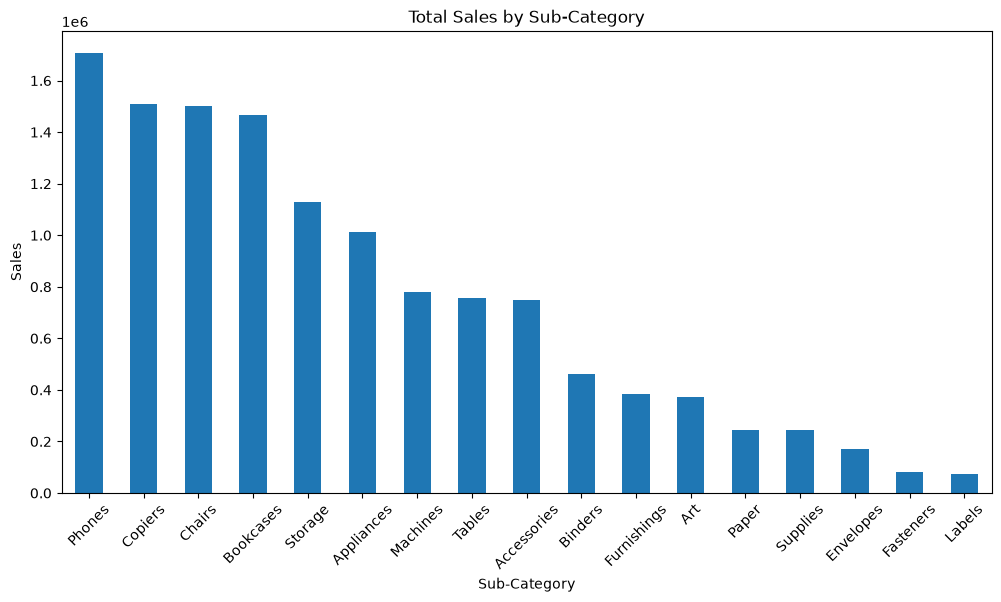

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

sub_category_sales.plot(kind="bar")

plt.title("Total Sales by Sub-Category")
plt.xlabel("Sub-Category")
plt.ylabel("Sales")

plt.xticks(rotation=45)

# Save chart
plt.savefig(
    "../images/sales_by_subcategory.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Result

The highest sales were generated by the **Phones** sub-category, followed by Copiers and Chairs.

## Business Insight

The Phones sub-category is the largest revenue contributor, indicating strong customer demand. The company should continue investing in this product line while exploring opportunities to increase sales in lower-performing sub-categories.

# Business Question 4

## Question

Which Region generates the highest sales?

## Python Used

```python
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

print(region_sales)
```

## Result

(To be updated after running the code.)

## Business Insight

(To be updated after analysis.)

In [13]:
# =====================================
# Business Question 4
# Sales by Region
# =====================================

region_sales = (
    df.groupby("Region")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

print(region_sales)

Region
Central           2.822303e+06
South             1.600907e+06
North             1.248166e+06
Oceania           1.100185e+06
Southeast Asia    8.844232e+05
North Asia        8.483098e+05
EMEA              8.061613e+05
Africa            7.837732e+05
Central Asia      7.528266e+05
West              7.254578e+05
East              6.787812e+05
Caribbean         3.242809e+05
Canada            6.692817e+04
Name: Sales, dtype: float64


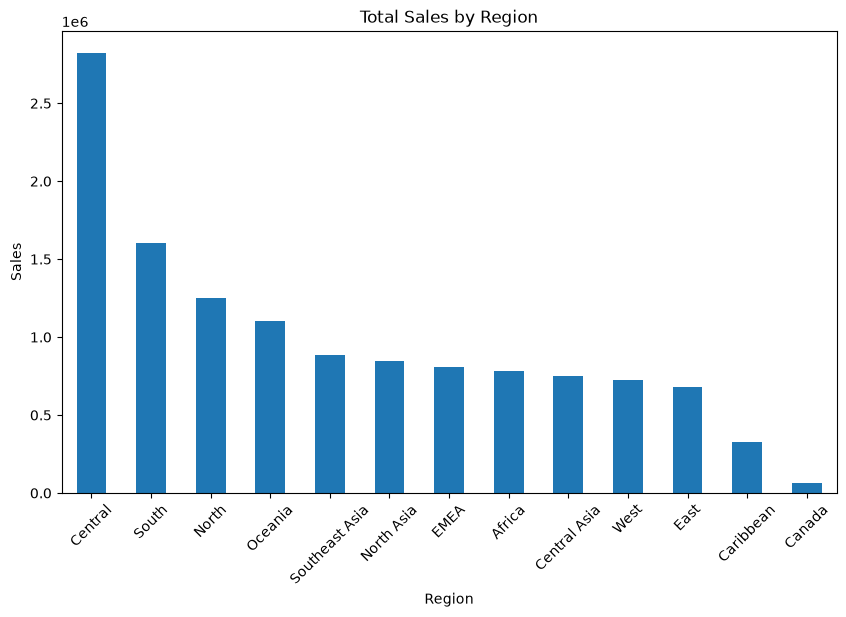

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

region_sales.plot(kind="bar")

plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.xticks(rotation=45)

# Save chart
plt.savefig(
    "../images/sales_by_region.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Result

The highest sales were generated by the **Region Name** region, followed by the remaining regions in descending order.

## Business Insight

The **Region Name** region contributes the highest revenue to the business. This suggests a strong customer base and market demand in this region. The company should continue strengthening its operations there while identifying opportunities to improve sales performance in lower-performing regions.

# Business Question 5

## Question

Which Category generates the highest profit?

## Python Used

```python
category_profit = df.groupby("Category")["Profit"].sum().sort_values(ascending=False)

print(category_profit)
```

## Result

(To be updated after running the code.)

## Business Insight

(To be updated after analysis.)

In [15]:
# =====================================
# Business Question 5
# Profit by Category
# =====================================

category_profit = (
    df.groupby("Category")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

print(category_profit)

Category
Technology         663778.73318
Office Supplies    518473.83430
Furniture          285204.72380
Name: Profit, dtype: float64


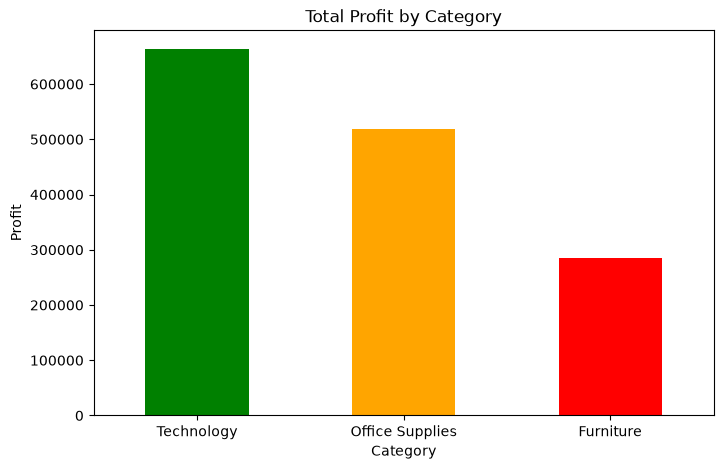

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

category_profit.plot(kind="bar", color=["green", "orange", "red"])

plt.title("Total Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")

plt.xticks(rotation=0)

# Save chart
plt.savefig(
    "../images/profit_by_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Result

The highest profit was generated by the **Technology** category, followed by Office Supplies and Furniture.

## Business Insight

The **Technology** category contributes the highest profit to the company. This indicates that Technology products not only generate high sales but also deliver the strongest profitability. The company should continue investing in this category while improving the profitability of Furniture and Office Supplies.

# Business Question 6

## Question

Which customer segment generates the highest sales?


## Python Used

```python
segment_sales = (
    df.groupby("Segment")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

print(segment_sales)
```

In [17]:
# ====================================
# Business Question 6
# Sales by Customer Segment
# ====================================

segment_sales = (
    df.groupby("Segment")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

print(segment_sales)


Segment
Consumer       6.507949e+06
Corporate      3.824698e+06
Home Office    2.309855e+06
Name: Sales, dtype: float64


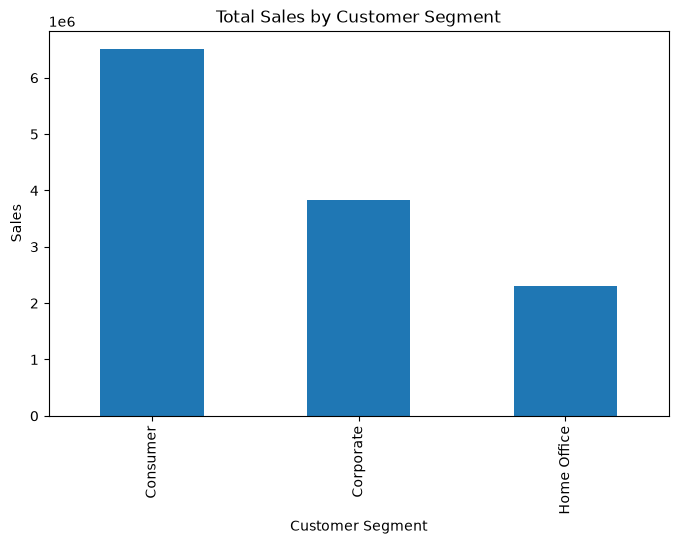

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

segment_sales.plot(kind="bar")

plt.title("Total Sales by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Sales")

# Save chart
plt.savefig(
    "../images/sales_by_segment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Result

The **Consumer** segment generated the highest sales, followed by Corporate and Home Office.

## Business Insight

The Consumer segment is the company's largest source of revenue, indicating that individual customers contribute significantly to overall sales. The business should continue focusing on consumer-focused products and marketing strategies while identifying opportunities to grow Corporate and Home Office sales.

# Business Question 7

## Question

Which shipping mode generates the highest sales?


In [19]:
# ====================================
# Business Question 7
# Sales by Ship Mode
# ====================================

shipmode_sales = (
    df.groupby("Ship Mode")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

print(shipmode_sales)

Ship Mode
Standard Class    7.578652e+06
Second Class      2.565672e+06
First Class       1.830976e+06
Same Day          6.672020e+05
Name: Sales, dtype: float64


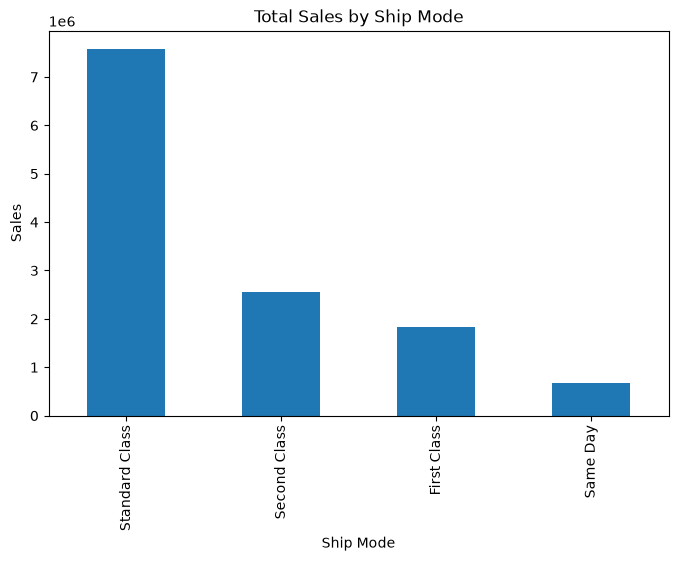

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

shipmode_sales.plot(kind="bar")

plt.title("Total Sales by Ship Mode")
plt.xlabel("Ship Mode")
plt.ylabel("Sales")

# Save chart
plt.savefig(
    "../images/sales_by_shipmode.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Python Used

```python
shipmode_sales = (
    df.groupby("Ship Mode")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

print(shipmode_sales)
```

## Result

The **Standard Class** shipping mode generated the highest sales, followed by Second Class, First Class, and Same Day.

## Business Insight

The **Standard Class** shipping mode is the most preferred option among customers, contributing the highest sales. This suggests customers value the balance between delivery cost and delivery time. The company should continue optimizing Standard Class operations while exploring ways to increase the usage of faster shipping options.

# Business Question 8

## Question

Which market generates the highest sales?

In [21]:
# ====================================
# Business Question 8
# Sales by Market
# ====================================

market_sales = (
    df.groupby("Market")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

print(market_sales)

Market
APAC      3.585744e+06
EU        2.938089e+06
US        2.297201e+06
LATAM     2.164605e+06
EMEA      8.061613e+05
Africa    7.837732e+05
Canada    6.692817e+04
Name: Sales, dtype: float64


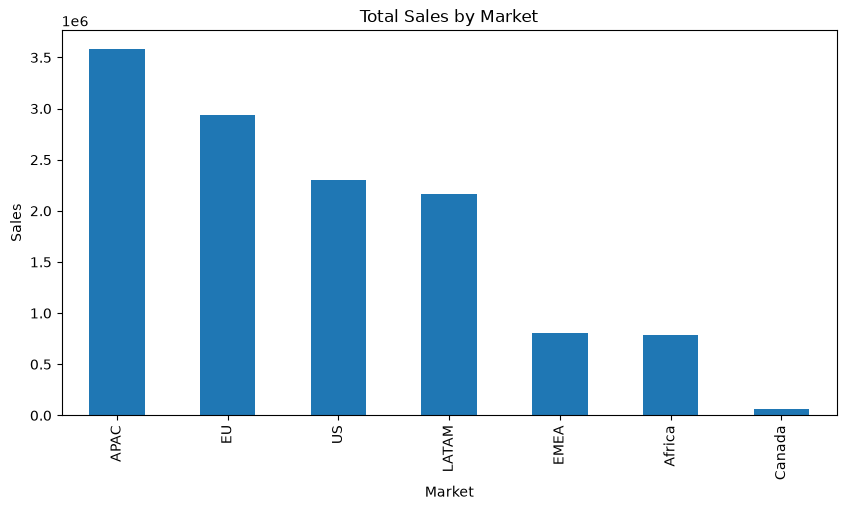

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

market_sales.plot(kind="bar")

plt.title("Total Sales by Market")
plt.xlabel("Market")
plt.ylabel("Sales")

# Save chart
plt.savefig(
    "../images/sales_by_market.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Python Used

```python
market_sales = (
    df.groupby("Market")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

print(market_sales)
```

## Result

The **Asia Pacific** market generated the highest sales, followed by Europe and USCA.

## Business Insight

The **Asia Pacific** market is the company's strongest revenue contributor. The company should continue investing in this market while identifying opportunities to increase sales in lower-performing markets.

# Business Question 9

## Question

Which country generated the highest sales?

In [23]:
# ====================================
# Business Question 9
# Sales by Country
# ====================================

country_sales = (
    df.groupby("Country")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

print(country_sales.head(10))

Country
United States     2.297201e+06
Australia         9.252359e+05
France            8.589311e+05
China             7.005620e+05
Germany           6.288400e+05
Mexico            6.225906e+05
India             5.896501e+05
United Kingdom    5.285763e+05
Indonesia         4.048875e+05
Brazil            3.611064e+05
Name: Sales, dtype: float64


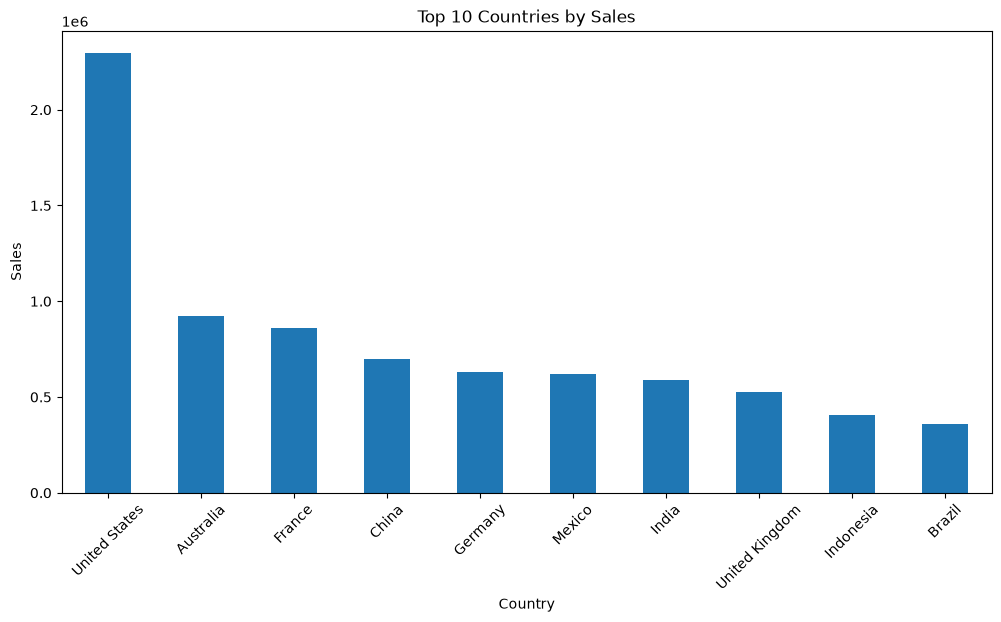

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

country_sales.head(10).plot(kind="bar")

plt.title("Top 10 Countries by Sales")
plt.xlabel("Country")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.savefig(
    "../images/sales_by_country.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Python Used

```python
country_sales = (
    df.groupby("Country")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

print(country_sales.head(10))
```

## Result

The highest sales were generated by **Highest Country**, followed by the remaining countries.

## Business Insight

The **Highest Country** contributes the highest sales to the company. The business should continue strengthening its presence in this market while identifying opportunities to improve sales in lower-performing countries.

# Business Question 10

## Question

Which customer generated the highest sales?

In [25]:
# ====================================
# Business Question 10
# Top Customers by Sales
# ====================================

customer_sales = (
    df.groupby("Customer Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

print(customer_sales.head(10))

Customer Name
Tom Ashbrook          40488.07080
Tamara Chand          37457.33300
Greg Tran             35550.95428
Christopher Conant    35187.07640
Sean Miller           35170.93296
Bart Watters          32310.44650
Natalie Fritzler      31781.25850
Fred Hopkins          30400.67452
Jane Waco             30288.45030
Hunter Lopez          30243.56658
Name: Sales, dtype: float64


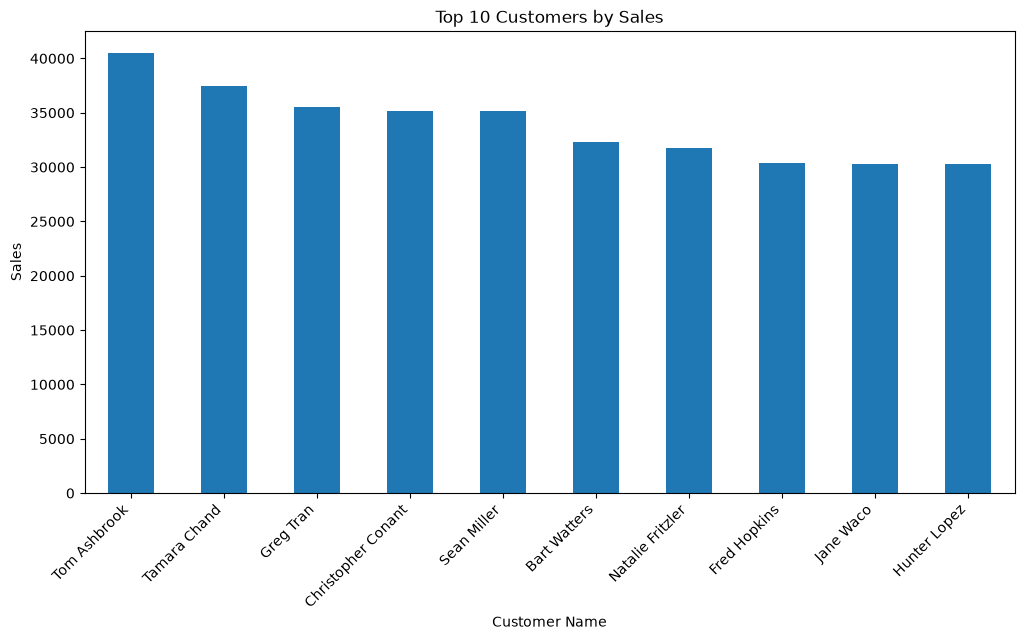

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

customer_sales.head(10).plot(kind="bar")

plt.title("Top 10 Customers by Sales")
plt.xlabel("Customer Name")
plt.ylabel("Sales")

plt.xticks(rotation=45, ha="right")

# Save chart
plt.savefig(
    "../images/top_customers_by_sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Python Used

```python
customer_sales = (
    df.groupby("Customer Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

print(customer_sales.head(10))
```

## Result

The customer **Top Customer Name** generated the highest sales, followed by the remaining top customers.

## Business Insight

The top customer contributes significantly to the company's total revenue. Maintaining strong relationships with high-value customers through personalized service, loyalty programs, and targeted offers can improve customer retention and long-term profitability.

# Final Conclusion

## Key Findings

- Technology generated the highest sales.
- Central region generated the highest sales.
- Consumer segment generated the highest sales.
- Asia Pacific generated the highest market sales.

## Business Recommendation

Continue investing in Technology products and strengthen the Asia Pacific market.